In [4]:
import pandas as pd
import json
import os
import mne

#### Since it is 5GB I am not storing the data in the repository.  Note I exit the repository before going into the local data folder.

In [5]:

data_path = os.path.join("..","LocalData","Dementia_Patients_EEG_Data")
data_path

'..\\LocalData\\Dementia_Patients_EEG_Data'

The subject of the study. Note that the MMSE score measures mental decline.


#### Let's take a look at one of the EEG recordings

In [21]:
subjects_data = pd.read_csv(f"{data_path}\participants.tsv", delimiter="\t")
subjects_data

<>:1: SyntaxWarning: invalid escape sequence '\p'
<>:1: SyntaxWarning: invalid escape sequence '\p'
C:\Users\smiga\AppData\Local\Temp\ipykernel_32052\695450609.py:1: SyntaxWarning: invalid escape sequence '\p'
  subjects_data = pd.read_csv(f"{data_path}\participants.tsv", delimiter="\t")


,participant_id,Gender,Age,Group,MMSE
0,sub-001,F,57,A,16
1,sub-002,F,78,A,22
2,sub-003,M,70,A,14
3,sub-004,F,67,A,20
4,sub-005,M,70,A,22
...,...,...,...,...,...
83,sub-084,F,71,F,24
84,sub-085,M,64,F,26
85,sub-086,M,49,F,26
86,sub-087,M,73,F,24


In [23]:
# Load the .set file
subject = "sub-001"


file_path = os.path.join(data_path, subject, "eeg", subject + "_task-eyesclosed_eeg.set")


eeg_data = mne.io.read_raw_eeglab( file_path, preload=True)

# Convert EEG data to a pandas DataFrame
eeg_df = eeg_data.to_data_frame()

# Display the first few rows
eeg_df.head()

,time,Fp1,Fp2,F3,F4,C3,C4,P3,P4,O1,O2,F7,F8,T3,T4,T5,T6,Fz,Cz,Pz
0,0.000,-189.892563,-141.845688,-107.373039,28.466799,-108.447258,-36.474609,-73.583984,173.486328,149.462891,156.201172,-19.873045,-112.158195,-59.130859,-12.158201,-78.271477,-131.396469,-103.271477,-18.212889,-126.708977
1,0.002,-180.419907,-137.353500,-100.048820,32.275391,-103.369133,-33.642578,-69.384766,177.099609,150.146484,161.279297,-4.345701,-108.544914,-54.736328,-9.423826,-75.537102,-128.173813,-98.681633,-14.404295,-122.900383
2,0.004,-166.992172,-135.058578,-105.761711,35.351562,-101.953117,-29.882812,-67.968742,180.078125,144.238281,160.546875,4.199220,-103.710930,-53.320312,-5.273437,-85.546867,-124.609367,-98.535149,-11.523437,-120.410149
3,0.006,-160.205063,-132.958969,-105.322258,38.037109,-99.755852,-27.099607,-65.869133,183.349609,144.482422,161.865234,5.908205,-99.365227,-50.927734,-2.392576,-84.912102,-121.044914,-95.556633,-9.326170,-118.212883
4,0.008,-159.326157,-124.462883,-104.150383,41.162109,-98.486320,-24.462891,-64.794914,184.619141,146.044922,163.427734,5.419923,-96.337883,-48.095699,-2.587890,-82.470695,-120.068352,-91.748039,-7.666015,-116.357414


#### The first subject
Using a 'stacked line plot' to display EEG readings.

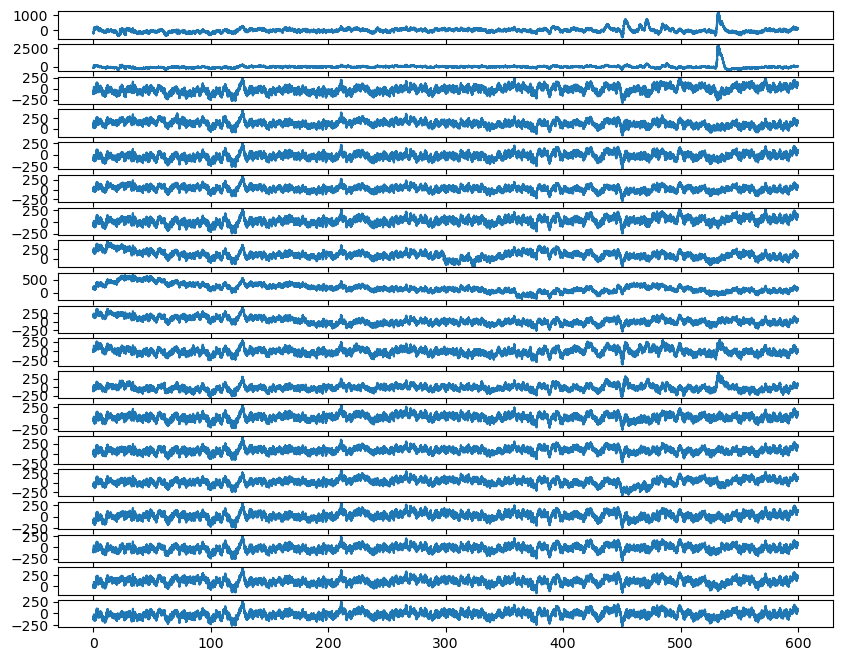

In [22]:
import matplotlib.pyplot as plt


eeg_sensors = eeg_df.columns[1:]

fig, axes = plt.subplots(19,1, figsize=(10,8), sharex=True)

for i, sensor in enumerate(eeg_sensors):
    axes[i].plot(eeg_df["time"], eeg_df[sensor], label = sensor)


plt.show()

#### Our MMSE scores

For fun lets look at Age VS MMSE Score VS Gender.

Here I create a custom color mapping to help with storytelling.

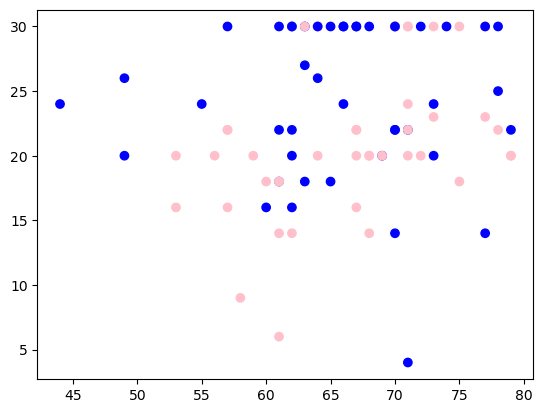

In [38]:

category_colors = {'F': 'pink', 'M': 'blue'}

subjects_data["Color"] = subjects_data["Gender"].map(category_colors)

plt.scatter( subjects_data["Age"],
             subjects_data["MMSE"],
             c=subjects_data["Color"])